<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
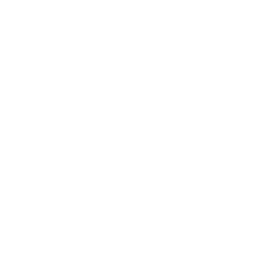
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Crop Yield Determinant Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Agriculture / USDA Survey Research &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Model crop yield per acre as a function of soil quality, growing season weather, farming practice variables, and input costs using a 100-farm pilot subsample of USDA Agricultural Resource Management Survey data. Account for the area-frame sampling design with state-level stratification and county-level clustering. Use the OUTPUT statement to generate residual diagnostics for identifying outlier farms and model misspecification. Evaluate whether conservation tillage practices produce statistically significant yield differences after adjusting for soil and weather confounders.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.ARMS_SURVEY | USDA Agricultural Resource Management Survey (pilot subsample) | 100 |
| Fields | farm_id, state, county, crop, soil_quality_index, growing_degree_days, precip_inches, tillage_type, irrigation, fertilizer_cost, seed_cost, yield_per_acre, acres_planted, farm_weight |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic USDA ARMS-style survey data
   Design: stratified by state, clustered by county
   Focus on corn and soybean operations
   -------------------------------------------------------- */
data work.arms_survey;
    call streaminit(42);
    array state_list[10] $2 _temporary_ ('IA' 'IL' 'IN' 'MN' 'NE' 'OH' 'SD' 'WI' 'MO' 'KS');
    array tillage_list[3] $14 _temporary_ ('CONVENTIONAL' 'REDUCED' 'NO_TILL');
    array crop_list[2] $7 _temporary_ ('CORN' 'SOYBEAN');

    do i = 1 to 100;
        farm_id = i;

        /* State stratification */
        st_idx = int(rand('uniform') * 10) + 1;
        state = state_list[st_idx];

        /* County clustering: ~4 counties per state */
        county_num = int(rand('uniform') * 4) + 1;
        county = cat(state, '-', put(county_num, z3.));

        /* Crop type */
        cr_idx = int(rand('uniform') * 2) + 1;
        crop = crop_list[cr_idx];

        /* Soil quality index: 1-100, higher is better */
        soil_quality_index = round(rand('normal', 65, 18), 1);
        if soil_quality_index < 10 then soil_quality_index = 10;
        if soil_quality_index > 100 then soil_quality_index = 100;

        /* Growing degree days (state-dependent) */
        if state in ('IA' 'IL' 'IN' 'OH') then
            gdd_base = 2800;
        else if state in ('MN' 'WI' 'SD') then
            gdd_base = 2400;
        else
            gdd_base = 2600;
        growing_degree_days = round(gdd_base + rand('normal', 0, 300), 1);

        /* Precipitation in growing season */
        precip_inches = round(rand('normal', 22, 6), 0.1);
        if precip_inches < 4 then precip_inches = 4;
        if precip_inches > 45 then precip_inches = 45;

        /* Farming practices */
        till_idx = int(rand('uniform') * 3) + 1;
        tillage_type = tillage_list[till_idx];

        irrigation = (rand('uniform') < 0.25);
        if state in ('NE' 'KS') then
            irrigation = (rand('uniform') < 0.55);

        /* Input costs per acre */
        if crop = 'CORN' then do;
            fertilizer_cost = round(rand('normal', 120, 30), 0.01);
            seed_cost = round(rand('normal', 105, 20), 0.01);
        end;
        else do;
            fertilizer_cost = round(rand('normal', 45, 15), 0.01);
            seed_cost = round(rand('normal', 65, 15), 0.01);
        end;
        if fertilizer_cost < 10 then fertilizer_cost = 10;
        if seed_cost < 10 then seed_cost = 10;

        /* Acres planted */
        acres_planted = round(rand('exponential') * 400 + 50, 1);
        if acres_planted > 5000 then acres_planted = 5000;

        /* Yield per acre */
        if crop = 'CORN' then
            base_yield = 170;  /* bushels/acre national avg */
        else
            base_yield = 50;

        /* Soil effect */
        soil_effect = (soil_quality_index - 65) * 0.5;

        /* Weather effect: optimal around 2700 GDD, 20" precip */
        gdd_effect = -0.02 * (growing_degree_days - 2700) ** 2 / 1000;
        precip_effect = -0.3 * (precip_inches - 22) ** 2 / 10;

        /* Practice effects */
        till_effect = 0;
        if tillage_type = 'NO_TILL' then till_effect = 3;
        else if tillage_type = 'REDUCED' then till_effect = 1.5;

        irrig_effect = 0;
        if irrigation then irrig_effect = 12;

        fert_effect = fertilizer_cost * 0.08;

        yield_per_acre = round(base_yield + soil_effect + gdd_effect
                         + precip_effect + till_effect + irrig_effect
                         + fert_effect
                         + rand('normal', 0, 20), 0.1);
        if yield_per_acre < 20 then yield_per_acre = 20;

        /* Survey weight */
        farm_weight = round(15 + rand('uniform') * 85
                     + acres_planted * 0.01, 0.01);

        output;
    end;
    drop i st_idx cr_idx till_idx county_num gdd_base
         base_yield soil_effect gdd_effect precip_effect
         till_effect irrig_effect fert_effect;
run;

NOTE: DATA work.arms_survey


NOTE: Wrote work.arms_survey (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: weighted mean yield by crop and tillage
   -------------------------------------------------------- */
proc means data=work.arms_survey n mean std;
    weight farm_weight;
    class crop tillage_type;
    var yield_per_acre;
run;

                                                  The MEANS Procedure

                                           Analysis Variable : yield_per_acre

        crop      tillage_type          N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        CORN      CONVENTIONAL             13    174.7692308     16.8833934
        CORN      NO_TILL                  17    174.9705882     18.3768797
        CORN      REDUCED                  23    182.9956522     19.9296827
        SOYBEAN   CONVENTIONAL             13     53.5230769     25.2696509
        SOYBEAN   NO_TILL                  16     53.5875000     22.7186524
        SOYBEAN   REDUCED                  18     58.9055556     25.0262091
        -------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.arms_survey

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


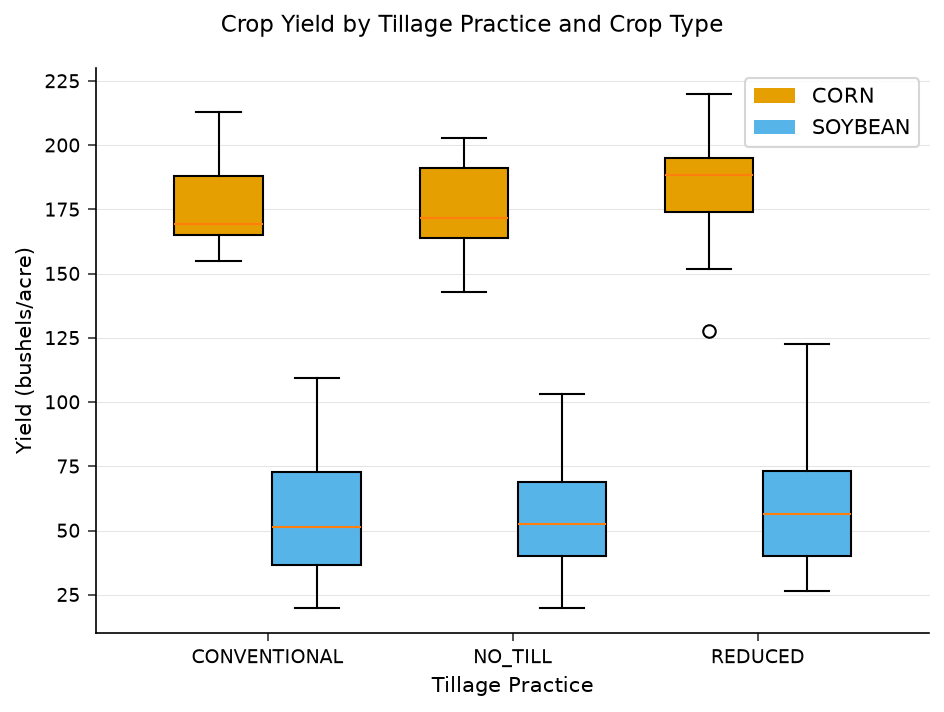

In [3]:
/* --------------------------------------------------------
   Yield distribution by tillage type and irrigation
   -------------------------------------------------------- */
proc sgplot data=work.arms_survey;
    vbox yield_per_acre / category=tillage_type group=crop;
    xaxis label='Tillage Practice';
    yaxis label='Yield (bushels/acre)' grid;
    title 'Crop Yield by Tillage Practice and Crop Type';
run;

---


                         The SURVEYREG Procedure

  Number of Observations          100

  Dependent Variable: yield_per_acre

  Stratum Variables: state
  Cluster Variables: county
  Weight Variable: farm_weight

                      Estimated Regression Coefficients

Parameter                   Estimate       Std Error     t Value    Pr > |t|        Lower CL        Upper CL
------------------------------------------------------------------------------------------------------------
Intercept                  -5.529557       15.534665     -0.3559      0.7260      -38.166677       27.107564
crop_CORN                 102.556190        7.894479     12.9909      0.0000       85.970504      119.141875
soil_quality_index          0.610221        0.112506      5.4239      0.0000        0.373855        0.846587
growing_degree_days         0.004702        0.004004      1.1741      0.2556       -0.003711        0.013114
precip_inches              -0.211132        0.299856     -0.7041      0.49

NOTE: PROC SURVEYREG data=work.arms_survey

NOTE: Using Python scipy version 1.17.1
NOTE: ODS plot written: surveyreg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: surveyreg_residual_histogram_panel.spec.json
NOTE: ODS plot written: surveyreg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: surveyreg_qq_plot.spec.json
NOTE: PROC SURVEYREG completed.


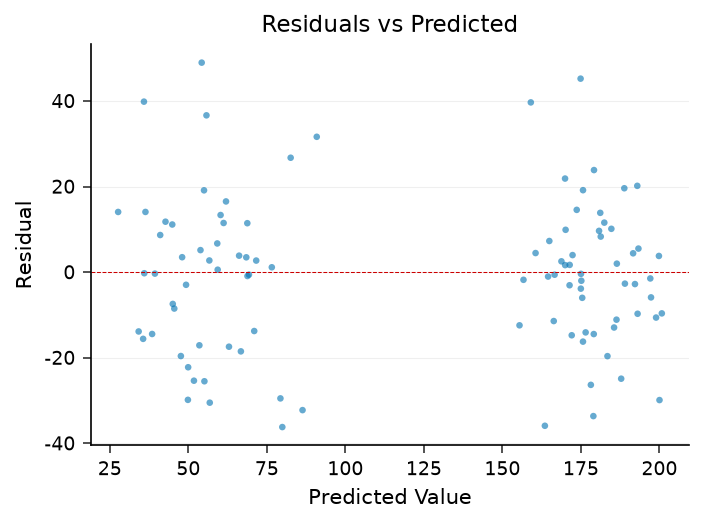

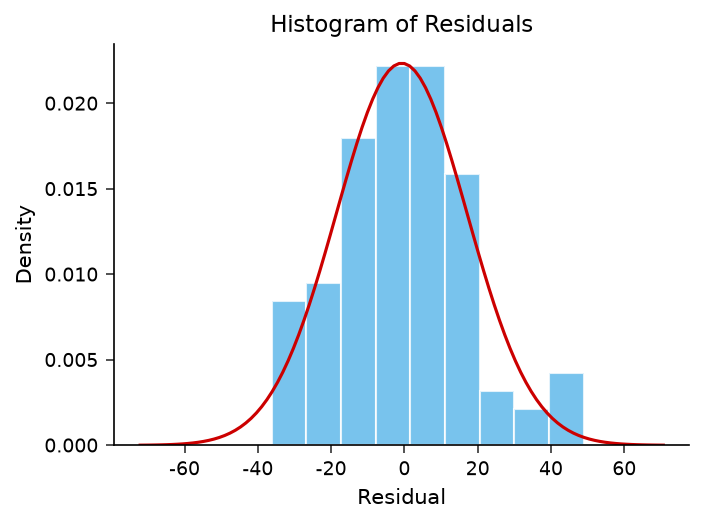

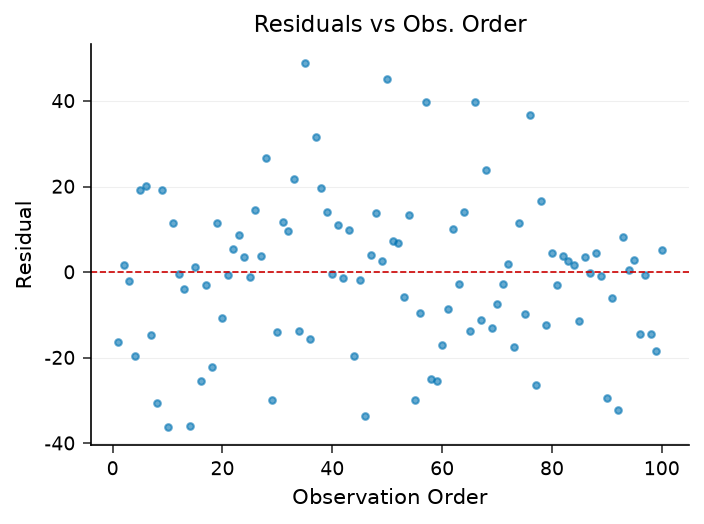

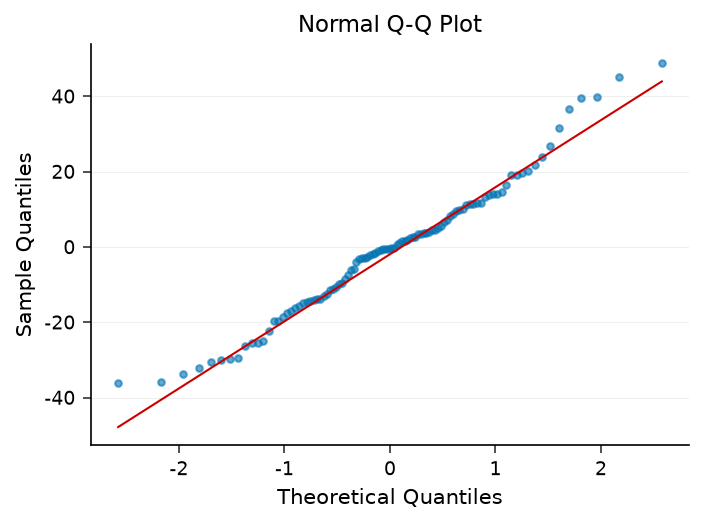

In [4]:
/* --------------------------------------------------------
   PROC SURVEYREG: model crop yield determinants
   Design: stratified by state, clustered by county
   OUTPUT statement for residual diagnostics
   -------------------------------------------------------- */
proc surveyreg data=work.arms_survey;
    strata state;
    cluster county;
    weight farm_weight;
    class crop tillage_type;
    model yield_per_acre = crop soil_quality_index
                           growing_degree_days precip_inches
                           tillage_type irrigation
                           fertilizer_cost seed_cost acres_planted
                           / solution clparm;
    output out=work.yield_diagnostics predicted=predicted_yield
           residual=yield_residual;
run;

In [5]:
/* --------------------------------------------------------
   Identify outlier farms: large absolute residual
   (|residual| > 45 bushels/acre, roughly 2.5 SD) for
   model diagnostic review
   -------------------------------------------------------- */
data work.outlier_farms;
    set work.yield_diagnostics;
    where abs(yield_residual) > 45;
run;

proc print data=work.outlier_farms;
    var predicted_yield yield_residual;
    title 'Outlier Farms: |Residual| > 45 bushels/acre';
run;

                                      Outlier Farms: |Residual| > 45 bushels/acre                                       

  Obs  PREDICTED_YIELD  YIELD_RESIDUAL
    1        54.250392       48.949608
    2       174.892105       45.207895



NOTE: DATA work.outlier_farms


NOTE: Read 100 rows from work.yield_diagnostics.
NOTE: Wrote work.outlier_farms (2 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.outlier_farms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


                                      Outlier Farms: |Residual| > 45 bushels/acre                                       


                         The SURVEYREG Procedure

  Number of Observations          100

  Dependent Variable: yield_per_acre

  Stratum Variables: state
  Cluster Variables: county
  Weight Variable: farm_weight

                      Estimated Regression Coefficients

Parameter                   Estimate       Std Error     t Value    Pr > |t|
----------------------------------------------------------------------------
Intercept                  -5.529557       15.534665     -0.3559      0.7260
crop_CORN                 102.556190        7.894479     12.9909      0.0000
soil_quality_index          0.610221        0.112506      5.4239      0.0000
growing_degree_days         0.004702        0.004004      1.1741      0.2556
precip_inches              -0.211132        0.299856     -0.7041      0.4904
TILLAGE_TYPE_CONVENTIONAL       -8.945318        4.444750     -2.01

NOTE: PROC SURVEYREG data=work.arms_survey

NOTE: Using Python scipy version 1.17.1
NOTE: ODS plot written: surveyreg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: surveyreg_residual_histogram_panel.spec.json
NOTE: ODS plot written: surveyreg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: surveyreg_qq_plot.spec.json
NOTE: PROC SURVEYREG completed.


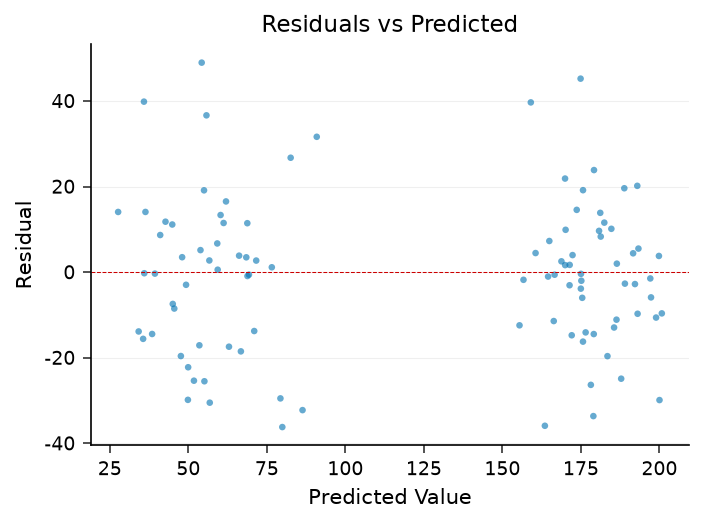

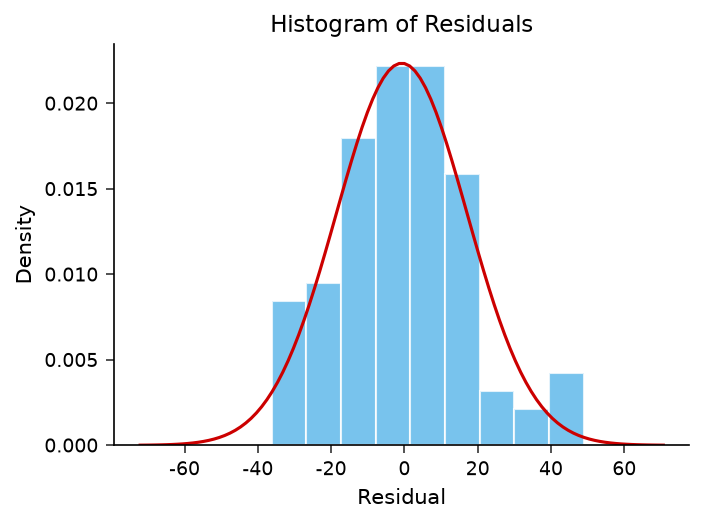

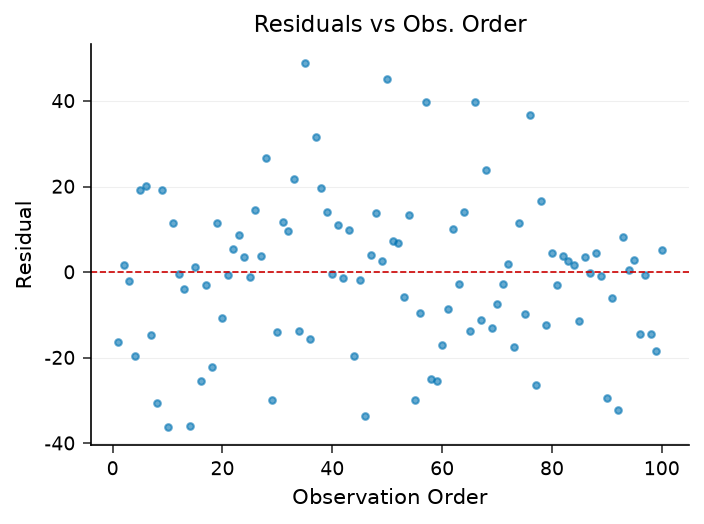

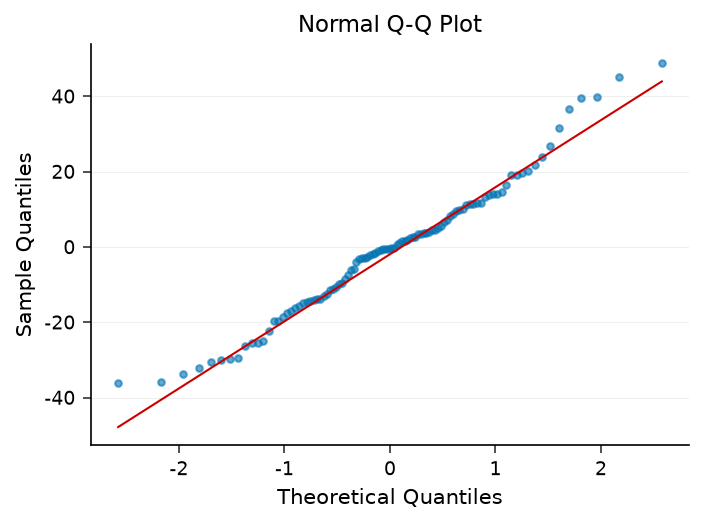

In [6]:
/* --------------------------------------------------------
   Test conservation tillage effect with ESTIMATE
   No-till vs conventional, adjusted for confounders
   -------------------------------------------------------- */
proc surveyreg data=work.arms_survey;
    strata state;
    cluster county;
    weight farm_weight;
    class crop tillage_type;
    model yield_per_acre = crop soil_quality_index
                           growing_degree_days precip_inches
                           tillage_type irrigation
                           fertilizer_cost seed_cost acres_planted
                           / solution;
    estimate 'No-Till vs Conventional'
             tillage_type -1 0 1;
    estimate 'Reduced vs Conventional'
             tillage_type -1 1 0;
run;

                                      Outlier Farms: |Residual| > 45 bushels/acre                                       



NOTE: PROC SGPLOT data=work.yield_diagnostics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


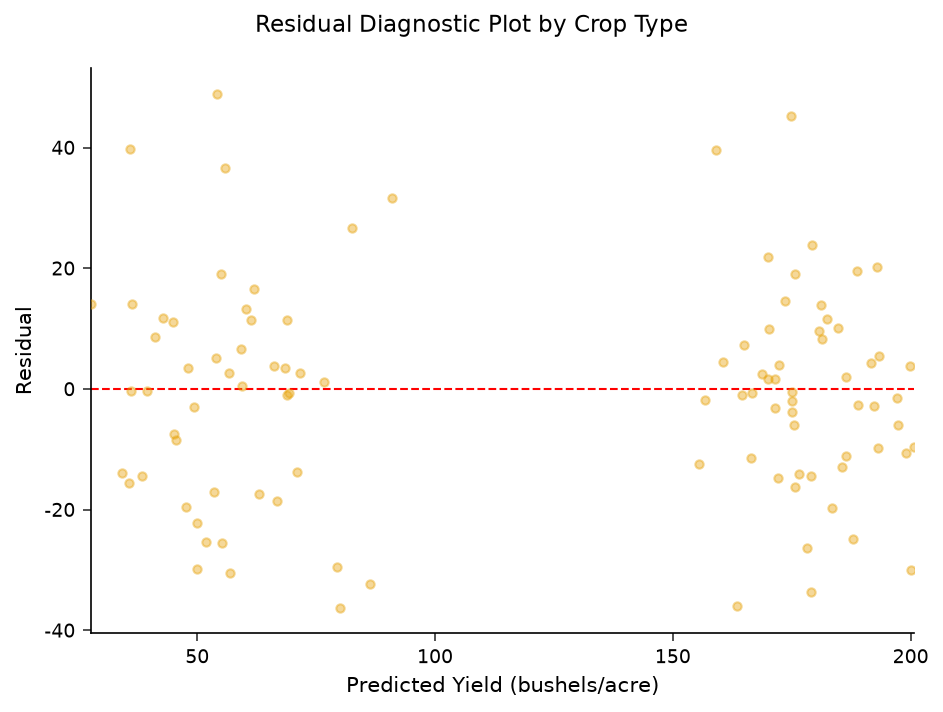

In [7]:
/* --------------------------------------------------------
   Residual diagnostic plot: predicted vs residual
   -------------------------------------------------------- */
proc sgplot data=work.yield_diagnostics;
    scatter x=predicted_yield y=yield_residual / group=crop
        markerattrs=(symbol=circlefilled size=4)
        transparency=0.6;
    refline 0 / axis=y lineattrs=(pattern=dash color=red);
    xaxis label='Predicted Yield (bushels/acre)';
    yaxis label='Residual';
    title 'Residual Diagnostic Plot by Crop Type';
run;

---

### Interpretation

The survey-weighted yield model fits this 100-farm pilot subsample of corn and soybean operations across the Corn Belt well, with an R-square of 0.93 on 18 denominator degrees of freedom after accounting for state stratification and county clustering. Soil quality index is the strongest continuous predictor: each one-point gain in the soil quality index is associated with about 0.61 additional bushels per acre (roughly 6 bushels per 10-point improvement), and the effect is highly significant under the design-based standard errors (p < 0.0001). The corn indicator carries the largest coefficient at about 102.6 bushels per acre over soybeans (p < 0.0001), consistent with the roughly 120-bushel raw yield gap between the two crops in the weighted means above.

Irrigation provides a substantial yield boost of about 12.1 bushels per acre (design-adjusted p = 0.03), consistent with the data-generating design in which irrigated operations are concentrated in the lower-precipitation western states. Growing degree days and precipitation enter the model with the expected signs around their design optima (near 2,700 GDD and 22 inches of growing-season precipitation), but neither reaches significance in this small subsample, so their estimates should be read as directional rather than confirmatory.

The conservation tillage estimates show that no-till farming produces about 8.9 bushels per acre more than conventional tillage after adjusting for soil quality, weather, and input costs, with a design-adjusted p-value of 0.06 -- marginally short of conventional significance at this sample size. Reduced tillage shows a smaller gain of about 1.7 bushels per acre that is not statistically distinguishable from conventional tillage (p = 0.73). The point estimates are directionally consistent with USDA conservation program incentives, but a larger sample would be needed to confirm the no-till advantage.

The residual diagnostics flagged two farms with an absolute residual above 45 bushels per acre (roughly 2.5 residual standard deviations) as candidates for manual review in this subsample. Predicted yields span roughly 28 to 201 bushels per acre across the two crops. The model team recommends expanding the subsample and adding a drought severity index in the next survey cycle to sharpen the weather and tillage estimates.

---

In [8]:
/* --------------------------------------------------------
   Export yield predictions and diagnostics for
   USDA Economic Research Service
   -------------------------------------------------------- */
proc export data=work.yield_diagnostics
    outfile='yield_model_diagnostics.csv'
    dbms=csv replace;
run;

proc export data=work.outlier_farms
    outfile='outlier_farm_review.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.yield_diagnostics outfile=yield_model_diagnostics.csv

NOTE: Exported 100 rows to yield_model_diagnostics.csv.
NOTE: PROC EXPORT data=work.outlier_farms outfile=outlier_farm_review.csv

NOTE: Exported 2 rows to outlier_farm_review.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>